# Hierarchical Clustering

- Builds a tree of clusters (dendrogram) by repeatedly merging the closest clusters
- No need to pre-specify K — number of clusters is decided by reading the dendrogram
- Dataset: Mall_Customers.csv (same as K-Means, for comparison)
[https://www.kaggle.com/datasets/amisha0528/mall-customers-dataset](https://)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/Mall_Customers.csv')
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


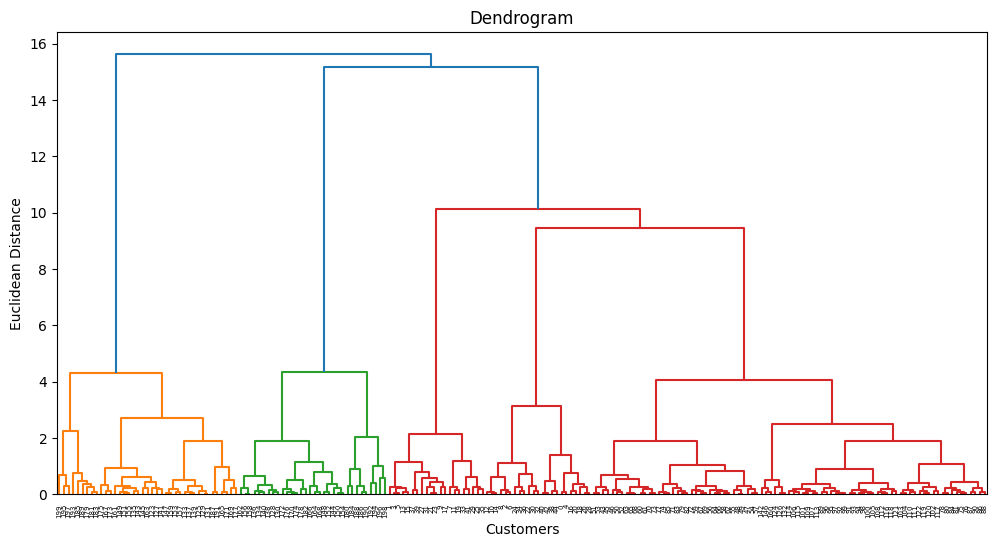

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch

sc = StandardScaler()
X_scaled = sc.fit_transform(X)

plt.figure(figsize=(12, 6))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method="ward"))
plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")
plt.show()

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        3  
2        4  
3        3  
4        4  


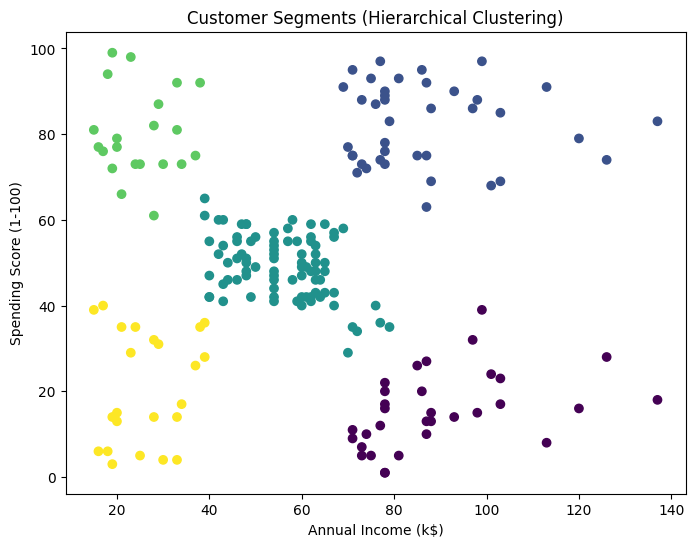

In [7]:
model = AgglomerativeClustering(n_clusters=5, metric="euclidean", linkage="ward")
clusters = model.fit_predict(X_scaled)

df["Cluster"] = clusters
print(df.head())

plt.figure(figsize=(8, 6))
plt.scatter(X["Annual Income (k$)"], X["Spending Score (1-100)"], c=clusters, cmap="viridis")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments (Hierarchical Clustering)")
plt.show()

## Conclusion
- The dendrogram showed the natural merge structure of customers without needing to pre-specify K
- Cutting the dendrogram at its tallest uncrossed line suggested 5 clusters — matching K-Means' result on the same data
- Ward's linkage merged clusters to keep within-cluster variance minimal at each step
- Hierarchical Clustering and K-Means agreeing on K=5 here gives more confidence that 5 is a genuine structure in the data, not an artifact of one method